# 10. Model Family Comparison

This notebook compares multiple model families across multiple feature sets.

Comparison axes:

- Feature sets

  - `base`: existing temporal frequency + gap features
  - `base_plus_pattern`: temporal features + internal draw-pattern history
  - `base_plus_context`: temporal features + calendar/weather context
  - `full_feature_set`: temporal + pattern + context
- Model families
  - heuristic baselines
  - linear model
  - tree-based models
  - classifier chain
  - shallow neural network

The goal is to compare *which combinations remain most stable* under the same time-based holdout and rolling-backtest setup.


In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
PROJECT_ROOT = None
for candidate in candidates:
    if (candidate / "src").exists() and (candidate / "data").exists():
        PROJECT_ROOT = candidate
        break
    if (candidate / "app" / "src").exists() and (candidate / "app" / "data").exists():
        PROJECT_ROOT = candidate / "app"
        break

if PROJECT_ROOT is None:
    raise RuntimeError(f"Could not locate app root from {cwd}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT


PosixPath('/workspace')

In [2]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.multioutput import MultiOutputClassifier

from src.config import PROCESSED_LOTTO_FILE, WEATHER_CONTEXT_FILE
from src.features.build_features import build_feature_dataset
from src.features.temporal_features import align_features_and_labels, time_based_train_test_split
from src.models.model_suite import LABEL_COLS, NUMBER_COLS, evaluate_probability_model, evaluate_number_predictions, probability_matrix_to_number_lists
from src.models.train_baseline import (
    build_classifier_chain_model,
    build_logistic_regression_model,
)
from src.models.train_random_forest import build_random_forest_model
from src.models.train_xgboost import build_xgboost_model
from src.visualization import save_report_figure, save_report_table

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)
np.random.seed(42)


## Configuration


In [3]:
WINDOW = 20
TEST_RATIO = 0.2
RANDOM_SEED = 42
BACKTEST_INITIAL_TRAIN_SIZE = 600
BACKTEST_TEST_SIZE = 30
BACKTEST_STEP_SIZE = 30
MAX_BACKTEST_FOLDS = 10

FEATURE_SET_NAMES = [
    "base",
    "base_plus_pattern",
    "base_plus_context",
    "full_feature_set",
]

MODEL_NAMES = [
    "freq_heuristic",
    "gap_heuristic",
    "random_baseline",
    "logistic_regression",
    "random_forest",
    "xgboost",
    "classifier_chain",
    "mlp",
]

BACKTEST_MODEL_NAMES = [
    "freq_heuristic",
    "gap_heuristic",
    "random_baseline",
    "logistic_regression",
    "xgboost",
    "classifier_chain",
    "mlp",
]


## Load Base Datasets


In [4]:
feature_df = build_feature_dataset(window=WINDOW)
clean_df = pd.read_csv(PROCESSED_LOTTO_FILE, low_memory=False)
weather_df = pd.read_csv(WEATHER_CONTEXT_FILE, low_memory=False)
weather_df["draw_date"] = pd.to_datetime(weather_df["draw_date"], errors="coerce")
weather_df["draw_datetime_used"] = pd.to_datetime(weather_df["draw_datetime_used"], errors="coerce")

feature_df.shape, clean_df.shape, weather_df.shape


((1197, 90), (1217, 18), (1217, 24))

## Build Labels


In [5]:
label_df = pd.DataFrame(0, index=clean_df.index, columns=LABEL_COLS)
for i in range(len(clean_df)):
    nums = clean_df.loc[i, NUMBER_COLS].tolist()
    for num in nums:
        label_df.loc[i, f"y_{num}"] = 1

X_base, y = align_features_and_labels(feature_df, label_df, window=WINDOW)
target_rounds = clean_df.loc[WINDOW:, "round"].reset_index(drop=True)
X_base.shape, y.shape, target_rounds.shape


((1197, 90), (1197, 45), (1197,))

## Build Internal Pattern Features


In [6]:
draw_patterns = clean_df.copy()
draw_patterns["sum_main"] = draw_patterns[NUMBER_COLS].sum(axis=1)
draw_patterns["odd_count"] = draw_patterns[NUMBER_COLS].apply(lambda row: sum(int(v) % 2 for v in row), axis=1)
draw_patterns["low_count"] = draw_patterns[NUMBER_COLS].apply(lambda row: sum(int(v) <= 22 for v in row), axis=1)
draw_patterns["max_consecutive_run"] = draw_patterns[NUMBER_COLS].apply(
    lambda row: max(
        [1] + [
            sum(1 for _ in group)
            for _, group in __import__("itertools").groupby(np.diff(sorted(row)).tolist(), lambda diff: diff == 1)
        ]
    ) if len(row) > 0 else 0
)

def rolling_feature_block(df, cols, windows=(5, 10, 20)):
    out = pd.DataFrame(index=df.index)
    for col in cols:
        shifted = df[col].shift(1)
        out[f"{col}_prev"] = shifted
        for w in windows:
            out[f"{col}_mean_{w}"] = shifted.rolling(w).mean()
            out[f"{col}_std_{w}"] = shifted.rolling(w).std()
    return out

pattern_source_cols = ["sum_main", "odd_count", "low_count"]
pattern_df = rolling_feature_block(draw_patterns, pattern_source_cols)
pattern_df = pattern_df.loc[WINDOW:].reset_index(drop=True)
pattern_df = pattern_df.fillna(pattern_df.median(numeric_only=True)).fillna(0)
pattern_df.head()


,sum_main_prev,sum_main_mean_5,sum_main_std_5,sum_main_mean_10,sum_main_std_10,sum_main_mean_20,sum_main_std_20,odd_count_prev,odd_count_mean_5,odd_count_std_5,odd_count_mean_10,odd_count_std_10,odd_count_mean_20,odd_count_std_20,low_count_prev,low_count_mean_5,low_count_std_5,low_count_mean_10,low_count_std_10,low_count_mean_20,low_count_std_20
0,115.0,135.8,38.525316,141.8,32.324054,148.65,30.622102,1.0,2.6,1.341641,3.0,1.247219,3.05,1.190975,4.0,3.0,1.414214,2.7,1.159502,2.45,1.190975
1,116.0,128.6,38.102493,137.0,32.224904,145.85,30.933332,2.0,2.6,1.341641,2.8,1.229273,2.95,1.190975,4.0,3.4,1.341641,2.9,1.197219,2.60,1.187656
2,79.0,124.0,43.168275,130.6,36.914917,142.70,34.363536,3.0,2.4,1.140175,2.6,0.966092,2.90,1.165287,5.0,3.6,1.516575,3.1,1.370320,2.70,1.301821
3,128.0,126.8,42.810046,124.7,31.166399,142.85,34.288674,4.0,2.4,1.140175,2.7,1.059350,2.85,1.089423,4.0,3.6,1.516575,3.4,1.173788,2.70,1.301821
4,150.0,117.6,25.774018,127.3,32.169862,141.15,32.958147,4.0,2.8,1.303840,2.9,1.100505,2.95,1.099043,2.0,3.8,1.095445,3.3,1.251666,2.75,1.251315


## Build Calendar and Weather Context Features


In [7]:
calendar_weather = weather_df.copy()
calendar_weather["month"] = calendar_weather["draw_date"].dt.month
calendar_weather["year"] = calendar_weather["draw_date"].dt.year
calendar_weather["day_of_month"] = calendar_weather["draw_date"].dt.day
calendar_weather["season"] = pd.Categorical(
    np.select(
        [
            calendar_weather["month"].isin([12, 1, 2]),
            calendar_weather["month"].isin([3, 4, 5]),
            calendar_weather["month"].isin([6, 7, 8]),
        ],
        ["winter", "spring", "summer"],
        default="autumn",
    ),
    categories=["spring", "summer", "autumn", "winter"],
)

for col in [
    "temp_at_draw",
    "humidity_at_draw",
    "wind_at_draw",
    "pressure_at_draw",
    "precip_at_draw",
    "precip_day_cumulative_at_draw",
    "precip_1h",
    "precip_6h",
    "precip_24h",
    "snow_at_draw",
]:
    if col in calendar_weather.columns:
        calendar_weather[col] = pd.to_numeric(calendar_weather[col], errors="coerce")
        calendar_weather.loc[calendar_weather[col] < 0, col] = np.nan

calendar_weather["is_raining"] = calendar_weather["is_raining"].fillna(False).astype(int)
calendar_weather["is_snowing"] = calendar_weather["is_snowing"].fillna(False).astype(int)
calendar_weather["month_sin"] = np.sin(2 * np.pi * calendar_weather["month"] / 12)
calendar_weather["month_cos"] = np.cos(2 * np.pi * calendar_weather["month"] / 12)
calendar_weather["day_sin"] = np.sin(2 * np.pi * calendar_weather["day_of_month"] / 31)
calendar_weather["day_cos"] = np.cos(2 * np.pi * calendar_weather["day_of_month"] / 31)

calendar_cols = ["month_sin", "month_cos", "day_sin", "day_cos", "year"]
weather_cols = [
    "temp_at_draw",
    "humidity_at_draw",
    "wind_at_draw",
    "pressure_at_draw",
    "precip_at_draw",
    "precip_day_cumulative_at_draw",
    "precip_1h",
    "precip_6h",
    "precip_24h",
    "is_raining",
    "is_snowing",
]

calendar_weather = pd.concat([
    calendar_weather[["round"] + calendar_cols + weather_cols],
    pd.get_dummies(calendar_weather[["season"]], prefix="season", dtype=float),
    pd.get_dummies(calendar_weather[["temp_bin", "humidity_bin"]], dummy_na=True, dtype=float),
], axis=1)

context_df = pd.DataFrame({"round": target_rounds})
context_df = context_df.merge(calendar_weather, on="round", how="left")
for col in context_df.columns:
    if col == "round":
        continue
    if context_df[col].dtype.kind in "biufc":
        context_df[col] = context_df[col].fillna(context_df[col].median() if context_df[col].notna().any() else 0)
    else:
        context_df[col] = context_df[col].fillna(0)

context_df.head()


,round,month_sin,month_cos,day_sin,day_cos,year,temp_at_draw,humidity_at_draw,wind_at_draw,pressure_at_draw,precip_at_draw,precip_day_cumulative_at_draw,precip_1h,precip_6h,precip_24h,is_raining,is_snowing,season_spring,season_summer,season_autumn,season_winter,temp_bin_cold,temp_bin_freezing,temp_bin_hot,temp_bin_mild,temp_bin_warm,temp_bin_nan,humidity_bin_dry,humidity_bin_humid,humidity_bin_moderate,humidity_bin_very_humid,humidity_bin_nan
0,21,0.866025,-0.500000,-0.848644,0.528964,2003,15.1,65.0,2.7,1005.4,0.2,0.0,0.0,0.0,0.0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,22,0.500000,-0.866025,0.571268,0.820763,2003,18.7,48.0,0.8,1004.2,0.2,0.0,0.0,0.0,0.0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,23,0.500000,-0.866025,0.897805,-0.440394,2003,15.3,46.0,2.8,1007.8,0.2,0.0,0.0,0.0,0.0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,24,0.500000,-0.866025,-0.299363,-0.954139,2003,18.0,66.0,1.7,998.6,0.2,0.0,0.0,0.0,0.0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,25,0.500000,-0.866025,-0.988468,0.151428,2003,17.9,80.0,6.5,1004.0,0.1,0.0,0.0,0.0,0.0,1,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## Assemble Feature Sets


In [8]:
X_pattern = pattern_df.reset_index(drop=True)
X_context = context_df.drop(columns=["round"]).reset_index(drop=True)

feature_sets = {
    "base": X_base.reset_index(drop=True),
    "base_plus_pattern": pd.concat([X_base.reset_index(drop=True), X_pattern], axis=1),
    "base_plus_context": pd.concat([X_base.reset_index(drop=True), X_context], axis=1),
    "full_feature_set": pd.concat([X_base.reset_index(drop=True), X_pattern, X_context], axis=1),
}

{k: v.shape for k, v in feature_sets.items()}


{'base': (1197, 90),
 'base_plus_pattern': (1197, 111),
 'base_plus_context': (1197, 121),
 'full_feature_set': (1197, 142)}

## Model Builders and Evaluation Helpers


In [9]:
def random_predictions(n_rows: int, seed: int):
    rng = np.random.default_rng(seed)
    return [sorted(rng.choice(np.arange(1, 46), size=6, replace=False).tolist()) for _ in range(n_rows)]


def frequency_heuristic_predictions(X_frame: pd.DataFrame):
    freq_cols = [col for col in X_frame.columns if col.startswith("freq_")]
    return probability_matrix_to_number_lists(X_frame[freq_cols].to_numpy())


def gap_heuristic_predictions(X_frame: pd.DataFrame):
    gap_cols = [col for col in X_frame.columns if col.startswith("gap_")]
    return probability_matrix_to_number_lists(X_frame[gap_cols].to_numpy())


def build_mlp_model(random_seed: int):
    base = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=0.0005,
        batch_size=64,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        n_iter_no_change=15,
        random_state=random_seed,
    )
    return MultiOutputClassifier(base)


def build_model(model_name: str, random_seed: int):
    if model_name == "logistic_regression":
        return build_logistic_regression_model(random_seed=random_seed)
    if model_name == "random_forest":
        return build_random_forest_model(random_seed=random_seed)
    if model_name == "xgboost":
        return build_xgboost_model(random_seed=random_seed)
    if model_name == "classifier_chain":
        return build_classifier_chain_model(random_seed=random_seed)
    if model_name == "mlp":
        return build_mlp_model(random_seed=random_seed)
    raise ValueError(model_name)


def evaluate_feature_model_pair(feature_set_name, model_name, X_frame, y_frame, test_ratio=TEST_RATIO, random_seed=RANDOM_SEED):
    split = time_based_train_test_split(X_frame, y_frame, test_ratio=test_ratio)
    X_train = split["X_train"]
    X_test = split["X_test"]
    y_train = split["y_train"]
    y_test = split["y_test"]

    if model_name == "freq_heuristic":
        result = evaluate_number_predictions(model_name, frequency_heuristic_predictions(X_test), y_test, label_cols=LABEL_COLS)
    elif model_name == "gap_heuristic":
        result = evaluate_number_predictions(model_name, gap_heuristic_predictions(X_test), y_test, label_cols=LABEL_COLS)
    elif model_name == "random_baseline":
        result = evaluate_number_predictions(model_name, random_predictions(len(X_test), random_seed), y_test, label_cols=LABEL_COLS)
    else:
        model = build_model(model_name, random_seed=random_seed)
        model.fit(X_train, y_train)
        result = evaluate_probability_model(model_name, model, X_test, y_test)

    return {
        "feature_set": feature_set_name,
        "model": model_name,
        "subset_accuracy": result["subset_accuracy"],
        "number_level_accuracy": result["number_level_accuracy"],
        "avg_hit": result["avg_hit"],
        "hit_std": result["hit_std"],
        "n_train_rows": len(X_train),
        "n_test_rows": len(X_test),
    }


def rolling_backtest_feature_model_pair(feature_set_name, model_name, X_frame, y_frame, initial_train_size=BACKTEST_INITIAL_TRAIN_SIZE, test_size=BACKTEST_TEST_SIZE, step_size=BACKTEST_STEP_SIZE, random_seed=RANDOM_SEED, max_folds=MAX_BACKTEST_FOLDS):
    rows = []
    fold_idx = 0
    for train_end in range(initial_train_size, len(X_frame) - test_size + 1, step_size):
        if max_folds is not None and fold_idx >= max_folds:
            break
        test_end = train_end + test_size
        X_train = X_frame.iloc[:train_end].reset_index(drop=True)
        y_train = y_frame.iloc[:train_end].reset_index(drop=True)
        X_test = X_frame.iloc[train_end:test_end].reset_index(drop=True)
        y_test = y_frame.iloc[train_end:test_end].reset_index(drop=True)

        if model_name == "freq_heuristic":
            result = evaluate_number_predictions(model_name, frequency_heuristic_predictions(X_test), y_test, label_cols=LABEL_COLS)
        elif model_name == "gap_heuristic":
            result = evaluate_number_predictions(model_name, gap_heuristic_predictions(X_test), y_test, label_cols=LABEL_COLS)
        elif model_name == "random_baseline":
            result = evaluate_number_predictions(model_name, random_predictions(len(X_test), random_seed + fold_idx), y_test, label_cols=LABEL_COLS)
        else:
            model = build_model(model_name, random_seed=random_seed)
            model.fit(X_train, y_train)
            result = evaluate_probability_model(model_name, model, X_test, y_test)

        rows.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "fold": fold_idx,
            "subset_accuracy": result["subset_accuracy"],
            "number_level_accuracy": result["number_level_accuracy"],
            "avg_hit": result["avg_hit"],
        })
        fold_idx += 1

    return pd.DataFrame(rows)


## Holdout Comparison


In [10]:
holdout_rows = []
start_time = time.time()
for feature_set_name in FEATURE_SET_NAMES:
    X_frame = feature_sets[feature_set_name]
    for model_name in MODEL_NAMES:
        holdout_rows.append(evaluate_feature_model_pair(feature_set_name, model_name, X_frame, y))
holdout_full_results = pd.DataFrame(holdout_rows)
holdout_summary = holdout_full_results.sort_values(["avg_hit", "number_level_accuracy"], ascending=False).reset_index(drop=True)
print(f"Completed holdout comparison in {time.time() - start_time:.1f}s")
holdout_summary.head(12)


Completed holdout comparison in 561.1s


,feature_set,model,subset_accuracy,number_level_accuracy,avg_hit,hit_std,n_train_rows,n_test_rows
0,base_plus_pattern,classifier_chain,0.0,0.773519,0.904167,0.848518,957,240
1,base,classifier_chain,0.0,0.773333,0.900000,0.830662,957,240
2,base_plus_context,classifier_chain,0.0,0.773148,0.895833,0.847535,957,240
3,full_feature_set,classifier_chain,0.0,0.772593,0.883333,0.818366,957,240
4,base,logistic_regression,0.0,0.772037,0.870833,0.824105,957,240
5,base_plus_context,logistic_regression,0.0,0.771667,0.862500,0.812564,957,240
6,base_plus_pattern,logistic_regression,0.0,0.771481,0.858333,0.824579,957,240
7,base,random_baseline,0.0,0.770556,0.837500,0.709056,957,240
8,base_plus_pattern,random_baseline,0.0,0.770556,0.837500,0.709056,957,240
9,base_plus_context,random_baseline,0.0,0.770556,0.837500,0.709056,957,240


## Rolling Backtest Comparison


In [11]:
backtest_rows = []
start_time = time.time()
for feature_set_name in FEATURE_SET_NAMES:
    X_frame = feature_sets[feature_set_name]
    for model_name in BACKTEST_MODEL_NAMES:
        backtest_rows.append(rolling_backtest_feature_model_pair(feature_set_name, model_name, X_frame, y))
backtest_full_results = pd.concat(backtest_rows, ignore_index=True)
backtest_summary = backtest_full_results.groupby(["feature_set", "model"], as_index=False).agg(
    folds=("fold", "nunique"),
    mean_subset_accuracy=("subset_accuracy", "mean"),
    mean_number_level_accuracy=("number_level_accuracy", "mean"),
    mean_avg_hit=("avg_hit", "mean"),
    std_avg_hit=("avg_hit", "std"),
).sort_values(["mean_avg_hit", "mean_number_level_accuracy"], ascending=False).reset_index(drop=True)
print(f"Completed rolling backtest in {time.time() - start_time:.1f}s")
backtest_summary.head(12)


Completed rolling backtest in 2526.3s


,feature_set,model,folds,mean_subset_accuracy,mean_number_level_accuracy,mean_avg_hit,std_avg_hit
0,base,random_baseline,10,0.0,0.771407,0.856667,0.145763
1,base_plus_context,mlp,10,0.0,0.771407,0.856667,0.132451
2,base_plus_context,random_baseline,10,0.0,0.771407,0.856667,0.145763
3,base_plus_pattern,random_baseline,10,0.0,0.771407,0.856667,0.145763
4,full_feature_set,random_baseline,10,0.0,0.771407,0.856667,0.145763
5,base,gap_heuristic,10,0.0,0.771111,0.850000,0.121969
6,base_plus_context,gap_heuristic,10,0.0,0.771111,0.850000,0.121969
7,base_plus_pattern,gap_heuristic,10,0.0,0.771111,0.850000,0.121969
8,base_plus_pattern,mlp,10,0.0,0.771111,0.850000,0.162731
9,full_feature_set,gap_heuristic,10,0.0,0.771111,0.850000,0.121969


## Visual Comparison


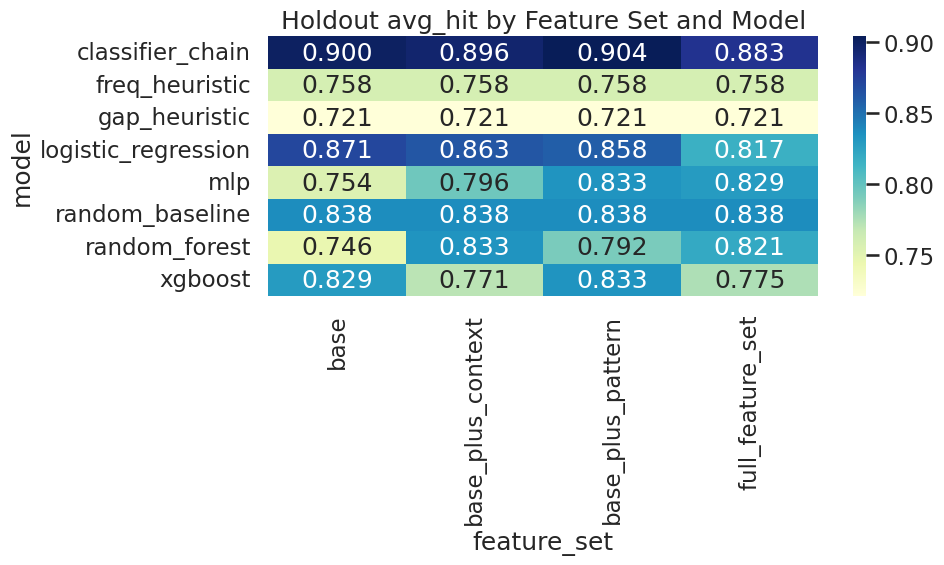

In [12]:
holdout_heatmap = holdout_summary.pivot(index="model", columns="feature_set", values="avg_hit")
fig_holdout_heatmap, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(holdout_heatmap, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax)
ax.set_title("Holdout avg_hit by Feature Set and Model")
plt.tight_layout()
plt.show()


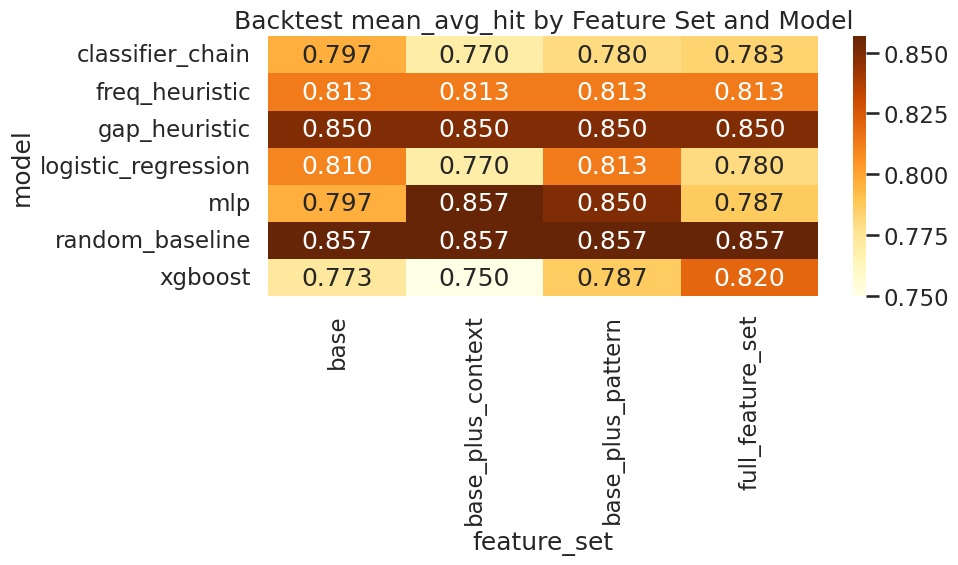

In [13]:
backtest_heatmap = backtest_summary.pivot(index="model", columns="feature_set", values="mean_avg_hit")
fig_backtest_heatmap, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(backtest_heatmap, annot=True, fmt=".3f", cmap="YlOrBr", ax=ax)
ax.set_title("Backtest mean_avg_hit by Feature Set and Model")
plt.tight_layout()
plt.show()


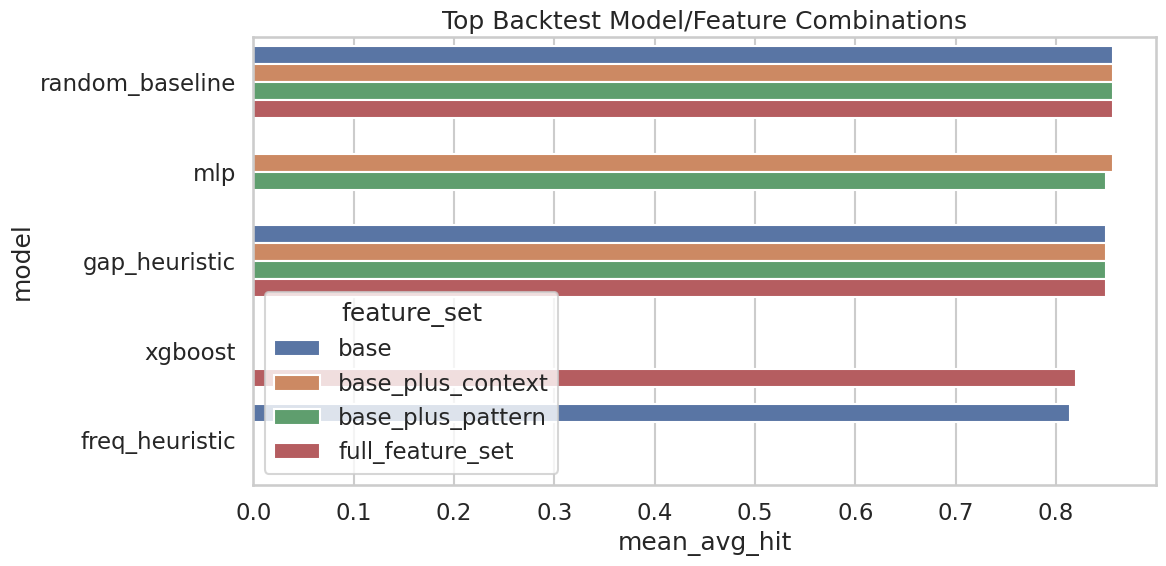

In [14]:
top_backtest = backtest_summary.head(12).copy()
fig_top_compare, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_backtest, x="mean_avg_hit", y="model", hue="feature_set", ax=ax)
ax.set_title("Top Backtest Model/Feature Combinations")
plt.tight_layout()
plt.show()


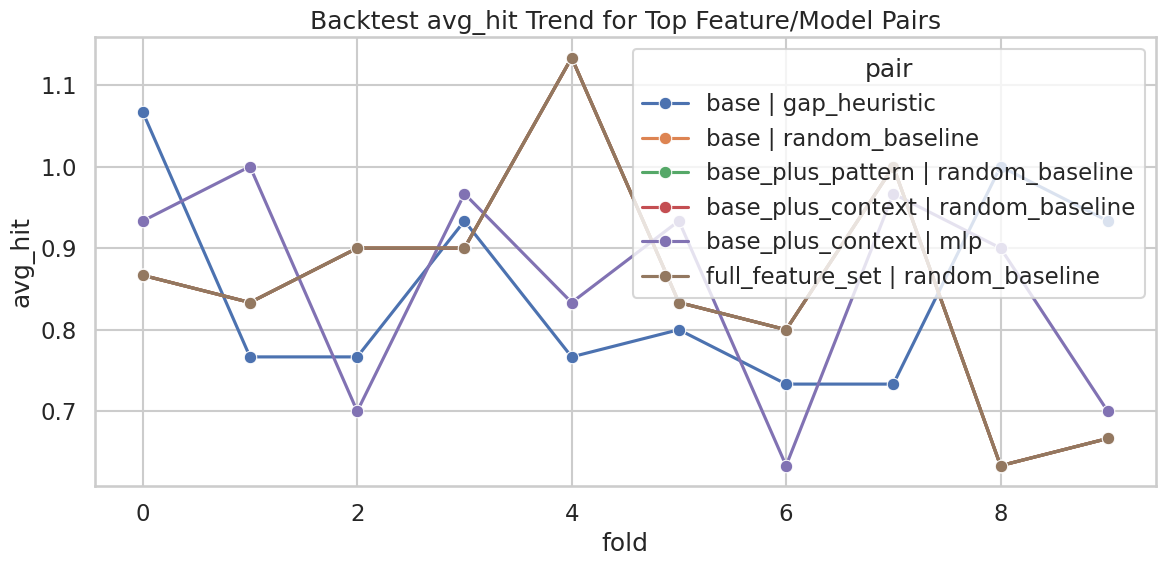

In [15]:
top_pairs = backtest_summary.head(6)[["feature_set", "model"]]
trend_df = backtest_full_results.merge(top_pairs, on=["feature_set", "model"], how="inner")
trend_df["pair"] = trend_df["feature_set"] + " | " + trend_df["model"]
fig_backtest_trend, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=trend_df, x="fold", y="avg_hit", hue="pair", marker="o", ax=ax)
ax.set_title("Backtest avg_hit Trend for Top Feature/Model Pairs")
plt.tight_layout()
plt.show()


## Interpretation Notes


In [16]:
display_cols_holdout = ["feature_set", "model", "avg_hit", "number_level_accuracy"]
display_cols_backtest = ["feature_set", "model", "mean_avg_hit", "mean_number_level_accuracy"]
holdout_summary[display_cols_holdout].head(12), backtest_summary[display_cols_backtest].head(12)


(          feature_set                model   avg_hit  number_level_accuracy
 0   base_plus_pattern     classifier_chain  0.904167               0.773519
 1                base     classifier_chain  0.900000               0.773333
 2   base_plus_context     classifier_chain  0.895833               0.773148
 3    full_feature_set     classifier_chain  0.883333               0.772593
 4                base  logistic_regression  0.870833               0.772037
 5   base_plus_context  logistic_regression  0.862500               0.771667
 6   base_plus_pattern  logistic_regression  0.858333               0.771481
 7                base      random_baseline  0.837500               0.770556
 8   base_plus_pattern      random_baseline  0.837500               0.770556
 9   base_plus_context      random_baseline  0.837500               0.770556
 10   full_feature_set      random_baseline  0.837500               0.770556
 11  base_plus_pattern              xgboost  0.833333               0.770370

Use the results conservatively:

- if `base` stays on top, the existing temporal features remain the most stable baseline
- if `base_plus_context` helps only some models, then calendar/weather is a model-dependent auxiliary signal
- if `full_feature_set` helps tree or neural models more than linear models, then feature interactions matter more than raw context alone
- rolling backtest matters more than a single holdout split when making final claims


## Report Export


In [17]:
save_report_figure(fig_holdout_heatmap, "fig_29_model_family_holdout_heatmap.png")
save_report_figure(fig_backtest_heatmap, "fig_30_model_family_backtest_heatmap.png")
save_report_figure(fig_top_compare, "fig_31_model_family_top_comparison.png")
save_report_figure(fig_backtest_trend, "fig_32_model_family_backtest_trend.png")

save_report_table(holdout_summary, "table_23_model_family_holdout_summary.csv")
save_report_table(backtest_summary, "table_24_model_family_backtest_summary.csv")
save_report_table(backtest_full_results, "table_25_model_family_full_results.csv")
print("Saved model family comparison report artifacts.")


Saved model family comparison report artifacts.
